# Detailed Records Analysis

This notebook analyzes the trading data from `detailed_records_framework_wf.csv`. It covers:
1.  **Asset Analysis**: Time series of assets traded, min/max counts.
2.  **Beta Analysis**: Distribution of beta values.
3.  **Exposure Analysis**: Daily net and gross exposure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. Load Data
df = pd.read_csv('detailed_records_framework_wf.csv')

# Convert date columns
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
if 'trade_date' in df.columns:
    df['trade_date'] = pd.to_datetime(df['trade_date'])

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3619 entries, 0 to 3618
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    3619 non-null   datetime64[ns]
 1   trade_date              3619 non-null   datetime64[ns]
 2   symbol                  3619 non-null   object        
 3   weight                  3619 non-null   float64       
 4   predicted_funding       3619 non-null   float64       
 5   actual_funding          3619 non-null   float64       
 6   price_change            3619 non-null   float64       
 7   price_return_contrib    3619 non-null   float64       
 8   funding_return_contrib  3619 non-null   float64       
 9   beta                    3619 non-null   float64       
 10  iteration               3619 non-null   int64         
dtypes: datetime64[ns](2), float64(7), int64(1), object(1)
memory usage: 311.1+ KB
None


,date,trade_date,symbol,weight,predicted_funding,actual_funding,price_change,price_return_contrib,funding_return_contrib,beta,iteration
0,2024-12-01,2024-11-30,1000RATSUSDT,-1.339860e-07,0.002020,0.002472,-0.021545,2.886681e-09,3.312522e-10,1.918795,1
1,2024-12-01,2024-11-30,KEYUSDT,2.976409e-01,-0.033189,0.000614,-0.058313,-1.735630e-02,-1.826175e-04,1.249653,1
2,2024-12-01,2024-11-30,MYROUSDT,-2.962042e-01,0.002686,0.002259,0.034331,-1.016901e-02,6.691549e-04,2.030048,1
3,2024-12-01,2024-11-30,NEIROETHUSDT,-1.162695e-08,0.002262,0.002194,0.027539,-3.201989e-10,2.551452e-11,1.705654,1
4,2024-12-01,2024-11-30,RENUSDT,3.000000e-01,-0.052724,-0.011337,-0.002732,-8.196729e-04,3.401067e-03,1.430844,1


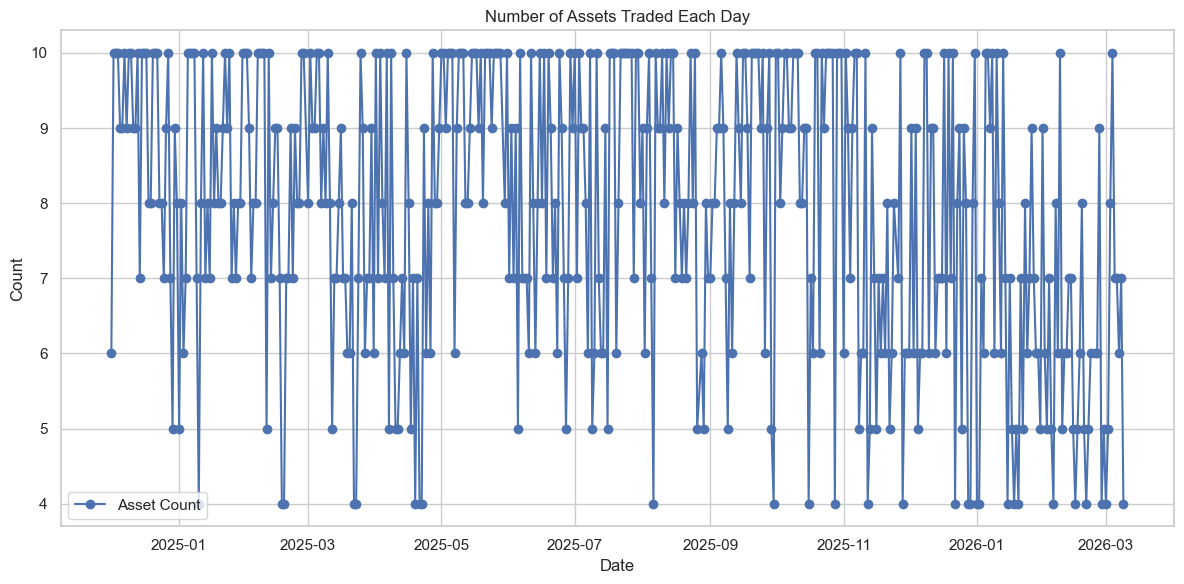

Minimum Assets Traded in a Day: 4 (on 2025-01-10)
Maximum Assets Traded in a Day: 10 (on 2024-12-02)
Average Assets Traded per Day: 7.88

Sample of assets traded in the last 5 days:
2026-03-05: 7 assets -> ['1000000BOBUSDT', 'B3USDT', 'BROCCOLIF3BUSDT', 'ENSOUSDT', 'PHAUSDT', 'PTBUSDT', 'SAHARAUSDT']
2026-03-06: 7 assets -> ['1000000BOBUSDT', 'BARDUSDT', 'JELLYJELLYUSDT', 'ORCAUSDT', 'PTBUSDT', 'SAHARAUSDT', 'SIRENUSDT']
2026-03-07: 6 assets -> ['1000000BOBUSDT', 'BANANAS31USDT', 'BARDUSDT', 'PTBUSDT', 'SAHARAUSDT', 'SENTUSDT']
2026-03-08: 7 assets -> ['BANANAS31USDT', 'BARDUSDT', 'KAVAUSDT', 'LAUSDT', 'MLNUSDT', 'SAHARAUSDT', 'SENTUSDT']
2026-03-09: 4 assets -> ['BABYUSDT', 'BROCCOLIF3BUSDT', 'DEGOUSDT', 'MBOXUSDT']


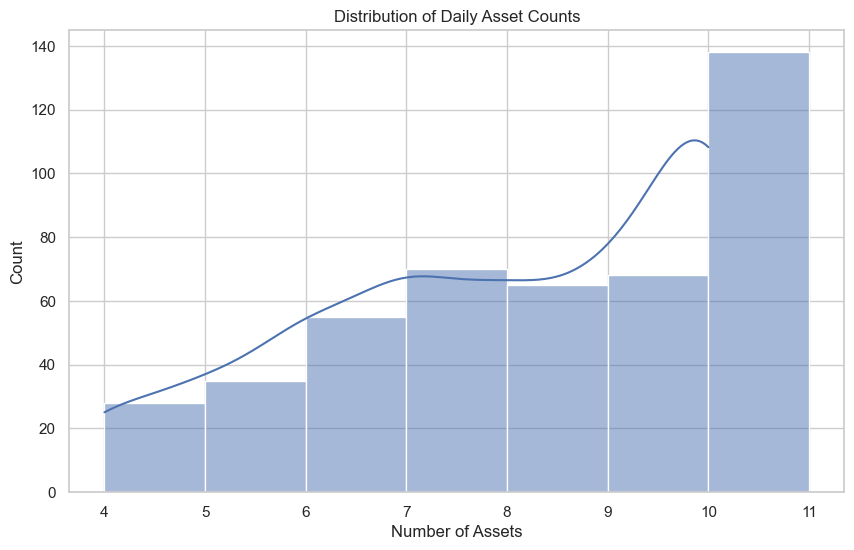

In [2]:
# 2. Time Series of Assets Traded (Count and List)
# Group by date to get unique assets and counts
daily_unique_assets = df.groupby('date')['symbol'].unique()
daily_asset_counts = df.groupby('date')['symbol'].nunique()

# Plot Daily Asset Count
plt.figure(figsize=(12, 6))
plt.plot(daily_asset_counts.index, daily_asset_counts.values, marker='o', linestyle='-', label='Asset Count')
plt.title('Number of Assets Traded Each Day')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# Display Min, Max, and Mean Asset Counts
min_count = daily_asset_counts.min()
max_count = daily_asset_counts.max()
mean_count = daily_asset_counts.mean()

print(f"Minimum Assets Traded in a Day: {min_count} (on {daily_asset_counts.idxmin().date()})")
print(f"Maximum Assets Traded in a Day: {max_count} (on {daily_asset_counts.idxmax().date()})")
print(f"Average Assets Traded per Day: {mean_count:.2f}")

# Sample of assets traded on the last 5 days
print("\nSample of assets traded in the last 5 days:")
for date, assets in daily_unique_assets.tail(5).items():
    print(f"{date.date()}: {len(assets)} assets -> {list(assets)}")

# Distribution of Asset Counts
plt.figure(figsize=(10, 6))
sns.histplot(daily_asset_counts, kde=True, bins=range(int(min_count), int(max_count)+2))
plt.title('Distribution of Daily Asset Counts')
plt.xlabel('Number of Assets')
plt.show()

Beta Statistics (Overall):
count    3619.000000
mean        1.337099
std         0.431899
min        -0.029110
25%         1.084571
50%         1.331511
75%         1.591664
max         3.315937
Name: beta, dtype: float64


/opt/anaconda3/envs/ds/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/ds/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/ds/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


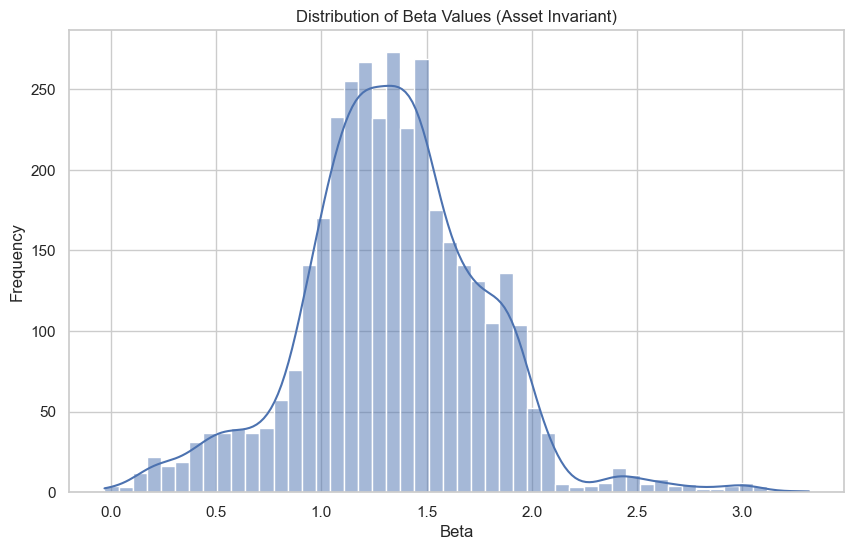

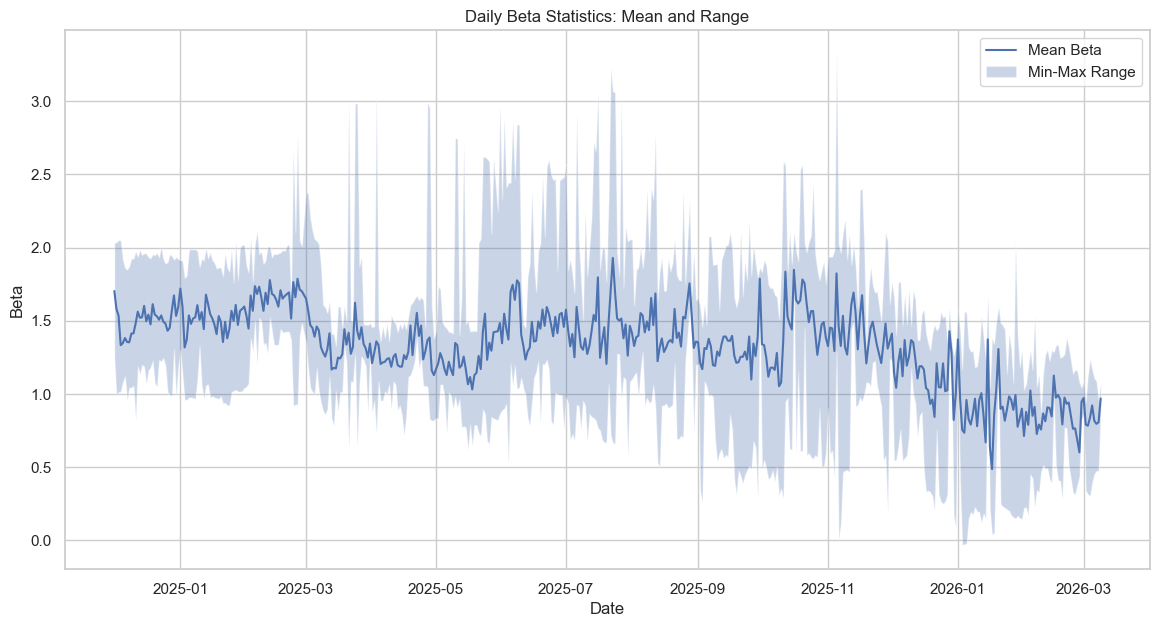

In [3]:
# 3. Beta Distribution (Asset Invariant)
if 'beta' in df.columns:
    print("Beta Statistics (Overall):")
    print(df['beta'].describe())
    
    # Histogram of Beta Values
    plt.figure(figsize=(10, 6))
    sns.histplot(df['beta'], kde=True, bins=50)
    plt.title('Distribution of Beta Values (Asset Invariant)')
    plt.xlabel('Beta')
    plt.ylabel('Frequency')
    plt.show()

    # Time series of Beta: Daily Min/Max/Mean
    beta_stats_daily = df.groupby('date')['beta'].agg(['min', 'max', 'mean', 'std'])
    
    plt.figure(figsize=(14, 7))
    plt.plot(beta_stats_daily.index, beta_stats_daily['mean'], label='Mean Beta')
    plt.fill_between(beta_stats_daily.index, beta_stats_daily['min'], beta_stats_daily['max'], alpha=0.3, label='Min-Max Range')
    plt.title('Daily Beta Statistics: Mean and Range')
    plt.xlabel('Date')
    plt.ylabel('Beta')
    plt.legend()
    plt.show()
else:
    print("Warning: 'beta' column not found in DataFrame.")

Exposure Statistics per Day:
       net_exposure  gross_exposure
count    459.000000      459.000000
mean       0.100771        0.999948
std        0.127489        0.001115
min       -0.256490        0.976120
25%        0.023137        1.000000
50%        0.096078        1.000000
75%        0.170415        1.000000
max        0.586916        1.000000


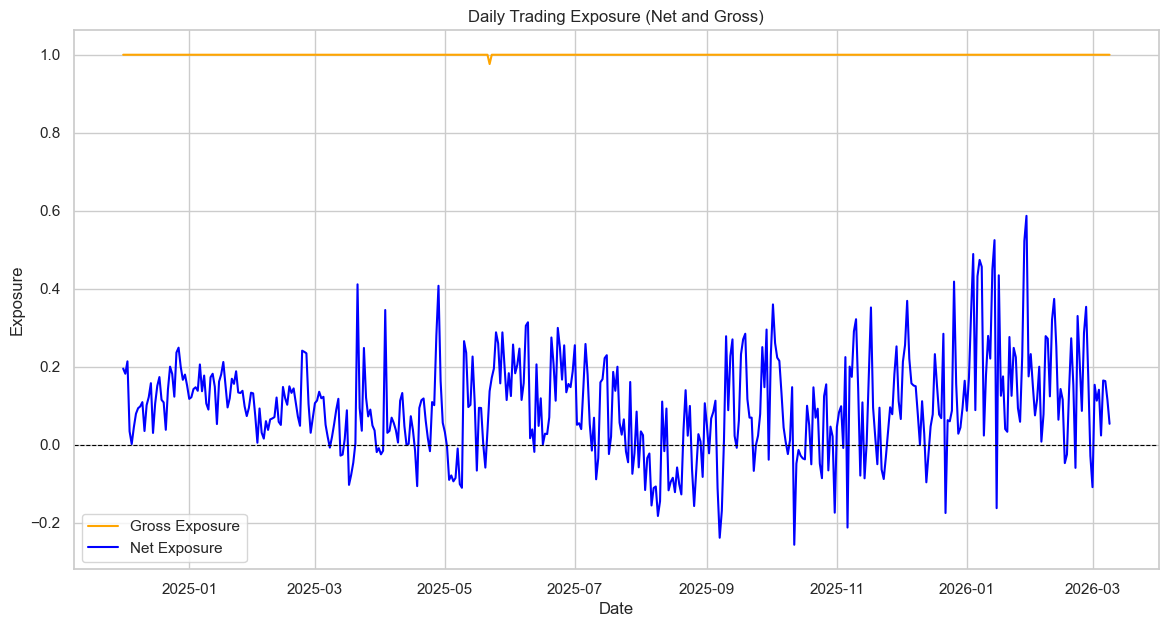

In [4]:
# 4. Exposure Analysis (Net and Gross)
# Assuming 'weight' represents the funding arbitrage position weight
if 'weight' in df.columns:
    daily_exposure = df.groupby('date')['weight'].agg(
        net_exposure=lambda x: x.sum(),
        gross_exposure=lambda x: x.abs().sum()
    )

    print("Exposure Statistics per Day:")
    print(daily_exposure.describe())

    plt.figure(figsize=(14, 7))
    plt.plot(daily_exposure.index, daily_exposure['gross_exposure'], label='Gross Exposure', color='orange')
    plt.plot(daily_exposure.index, daily_exposure['net_exposure'], label='Net Exposure', color='blue')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.title('Daily Trading Exposure (Net and Gross)')
    plt.xlabel('Date')
    plt.ylabel('Exposure')
    plt.legend()
    plt.show()
else:
    print("Warning: 'weight' column not found. Unable to calculate exposure.")